=== Scenario 2: Boosting ===
AdaBoost Accuracy: 1.0000
Gradient Boosting Accuracy: 1.0000


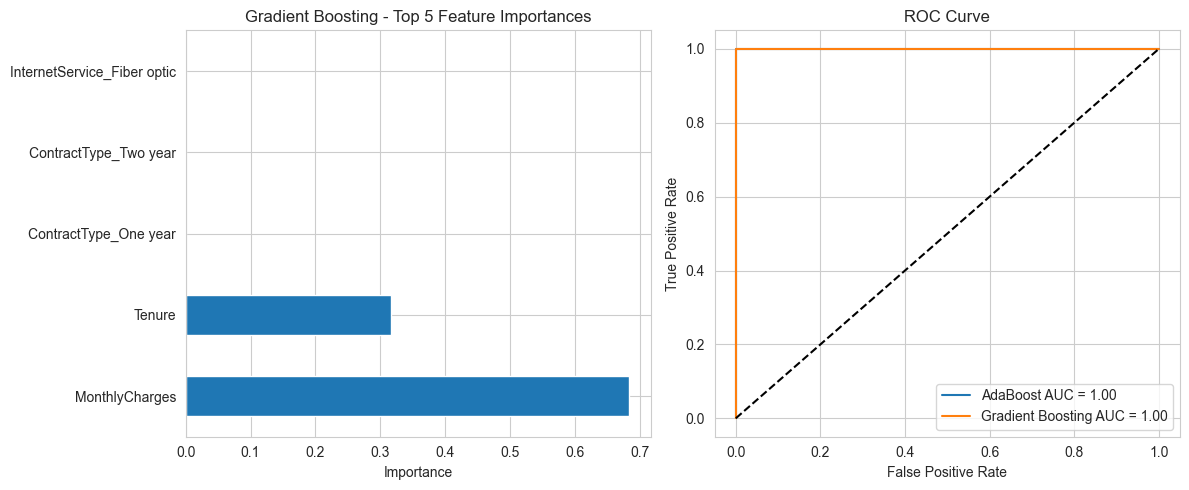

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_curve, auc

def main():
    # Load Data
    df = pd.read_csv('../dataset/churn_boosting.csv')

    target = 'Churn'
    # Encode categorical features
    df = pd.get_dummies(df, drop_first=True)

    X = df.drop(target, axis=1)
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train AdaBoost
    ada = AdaBoostClassifier(n_estimators=50, random_state=42)
    ada.fit(X_train, y_train)
    ada_pred = ada.predict(X_test)
    ada_acc = accuracy_score(y_test, ada_pred)

    # Train Gradient Boosting
    gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
    gb.fit(X_train, y_train)
    gb_pred = gb.predict(X_test)
    gb_acc = accuracy_score(y_test, gb_pred)

    print("=== Scenario 2: Boosting ===")
    print(f"AdaBoost Accuracy: {ada_acc:.4f}")
    print(f"Gradient Boosting Accuracy: {gb_acc:.4f}")

    # Visualization
    plt.figure(figsize=(12, 5))

    # Feature Importance (Gradient Boosting)
    plt.subplot(1, 2, 1)
    feat_importances = pd.Series(gb.feature_importances_, index=X.columns)
    feat_importances.nlargest(5).plot(kind='barh')
    plt.title('Gradient Boosting - Top 5 Feature Importances')
    plt.xlabel('Importance')

    # ROC Curve
    plt.subplot(1, 2, 2)
    ada_probs = ada.predict_proba(X_test)[:, 1]
    gb_probs = gb.predict_proba(X_test)[:, 1]

    fpr_a, tpr_a, _ = roc_curve(y_test, ada_probs)
    fpr_g, tpr_g, _ = roc_curve(y_test, gb_probs)

    plt.plot(fpr_a, tpr_a, label=f'AdaBoost AUC = {auc(fpr_a, tpr_a):.2f}')
    plt.plot(fpr_g, tpr_g, label=f'Gradient Boosting AUC = {auc(fpr_g, tpr_g):.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()

